<head>
    <style>
        .md-typeset h2 {
            margin:0;
            }
        .md-typeset h3 {
            margin:0;
            }
        .jupyter-wrapper table.dataframe tr, .jupyter-wrapper table.dataframe th, .jupyter-wrapper table.dataframe td {
            text-align:left;
            }
        .jupyter-wrapper table.dataframe {
            table-layout: auto;
            }
    </style>
</head>

# Data Collection 

In this post, we will construct our firm level dataset of all public firms 
from `NASDAQ`, `NYSE`, and `AMEX`. 

In [66]:
# import packages
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
plt.style.use('seaborn-notebook')  # set the theme

In [141]:
# requests headers
headers = """
authority: data.sec.gov
method: GET
scheme: https
accept: text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.9
accept-encoding: gzip, deflate, br
accept-language: en-US,en;q=0.9
cache-control: max-age=0
sec-fetch-dest: document
sec-fetch-mode: navigate
sec-fetch-site: none
sec-fetch-user: ?1
upgrade-insecure-requests: 1
user-agent: Mozilla/5.0 (iPhone; CPU iPhone OS 13_2_3 like Mac OS X) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/13.0.3 Mobile/15E148 Safari/604.1 Edg/103.0.5060.114
"""

headers = headers.strip().split('\n')
# save it as dict
HEADERS = {x.split(':')[0].strip():
           ("".join(x.split(':')[1:])).strip().replace('//',
                                                       "://") for x in headers}

## Stock Screener 

First of all, please download a list of public firms from
Nasdaq's official [website](https://www.nasdaq.com/market-activity/stocks/screener). 
After downloading it, we will try to have a big picture on those public firms. 

In [2]:
# read the dataset
stock_screener = pd.read_csv('./data/nasdaq_screener.csv')
stock_screener.head()

,Symbol,Name,Last Sale,Net Change,% Change,Market Cap,Country,IPO Year,Volume,Sector,Industry
0,A,Agilent Technologies Inc. Common Stock,$113.96,-4.6900,-3.953%,3.404077e+10,United States,1999.0,378311,Industrials,Electrical Products
1,AA,Alcoa Corporation Common Stock,$40.51,-2.6800,-6.205%,7.472016e+09,NaN,2016.0,2162446,Industrials,Metal Fabrications
2,AAC,Ares Acquisition Corporation Class A Ordinary ...,$9.85,0.0000,0.00%,1.231250e+09,NaN,2021.0,858,Finance,Business Services
3,AACG,ATA Creativity Global American Depositary Shares,$1.35,-0.0300,-2.174%,4.265809e+07,China,2008.0,4213,Consumer Discretionary,Service to the Health Industry
4,AACI,Armada Acquisition Corp. I Common Stock,$9.8803,-0.0005,-0.005%,2.046161e+08,United States,2021.0,5429,Industrials,Consumer Electronics/Appliances


In [3]:
stock_screener.shape

(8183, 11)

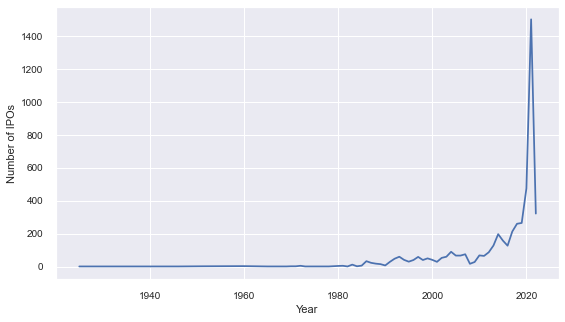

In [42]:
# visualize IPOs for each year
plt.subplots(1, 1, figsize=(9, 5))
year_list = stock_screener.groupby('IPO Year').size().plot()
year_list.set_xlabel("Year")
year_list.set_ylabel("Number of IPOs")
plt.show()

It looks like that we have so many IPOs during the pandemic. Considering the
big 'jump', we need to examine this phenomena again. 

In [5]:
stock_screener.groupby('IPO Year').size().nlargest(10)

IPO Year
2021.0    1501
2020.0     475
2022.0     322
2019.0     265
2018.0     260
2017.0     213
2014.0     197
2015.0     158
2013.0     128
2016.0     127
dtype: int64

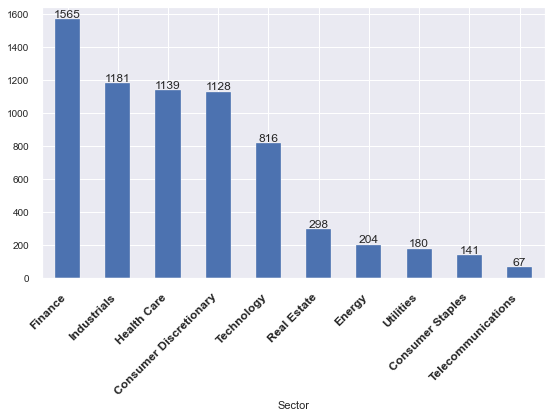

In [46]:
# firms cross countries
plt.subplots(1,1, figsize=(9, 5))
sector_dist = stock_screener.groupby('Sector').size().nlargest(10).plot.bar()
sector_dist.bar_label(sector_dist.containers[0])
plt.xticks(rotation=45, ha='right', fontsize=12, weight='bold')
plt.show()

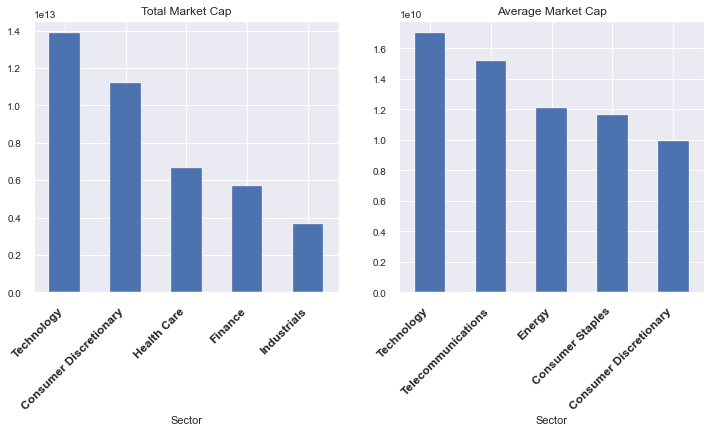

In [47]:
# visualize based on the cap
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
data = stock_screener.groupby('Sector')['Market Cap'].sum().nlargest()
data.plot.bar(ax=axes[0])
axes[0].set_title("Total Market Cap")
axes[0].set_xticklabels(data.index, rotation=45, ha='right', fontsize=12,
                        weight='bold')
stock_screener.groupby('Sector')['Market Cap'].mean().nlargest().plot.bar(ax=axes[1])
axes[1].set_title("Average Market Cap")
plt.xticks(rotation=45, ha='right', fontsize=12, weight='bold')
plt.show()

From the above figure, we know:

* technology and consumer discretionary sectors have the largest market capitalization
* technology and telecommunications have the highest average market cap

From now on, we will focus on two sectors: __technology__ and __telecommunications__. 

## Industry and Age Classification 

In this section, we will classify firms based on their industries and ages. Like
we said in the last section, we will focus on the analysis of information
technology (IT) sectors. Once we got a list of those firms, we will match
firm's `symbol` with its `CIK` number from SEC. 

The Central Index Key or CIK is a __10-digit__ number used on the Securities 
and Exchange Commission's computer systems to identify corporations and 
individuals who have filed disclosure with the SEC. To retrieve the data from
SEC, we need to make sure our CIK number is in 10 digit format. 


### Filter out the technology and telecommunication firms 

In [59]:
stock_screener['Sector'].unique()

array(['Industrials', 'Finance', 'Consumer Discretionary', 'Health Care',
       'Real Estate', nan, 'Technology', 'Energy', 'Consumer Staples',
       'Miscellaneous', 'Utilities', 'Telecommunications',
       'Basic Materials'], dtype=object)

In [177]:
def _sector_filter(sector_str, sector_conditions):
    if sector_str in sector_conditions:
        return True
    else:
        return False
it_industries = ['Technology', 'Telecommunications']
it_mask = stock_screener['Sector'].apply(lambda x: 
                                _sector_filter(x, it_industries))
it_firms = stock_screener[it_mask]

In [178]:
it_firms.head()

,Symbol,Name,Last Sale,Net Change,% Change,Market Cap,Country,IPO Year,Volume,Sector,Industry
17,AAOI,Applied Optoelectronics Inc. Common Stock,$1.57,-0.0400,-2.484%,4.338551e+07,United States,2013.0,2039,Technology,Semiconductors
20,AAPL,Apple Inc. Common Stock,$145.4894,-0.0006,0.00%,2.522399e+12,United States,1980.0,23406341,Technology,Computer Manufacturing
68,ACCD,Accolade Inc. Common Stock,$9.38,-0.1900,-1.985%,6.679445e+08,United States,2020.0,139680,Technology,Interactive Media
74,ACEV,ACE Convergence Acquisition Corp. Class A Ordi...,$10.17,0.0000,0.00%,1.418947e+08,United States,2020.0,462,Technology,Semiconductors
75,ACEVU,ACE Convergence Acquisition Corp. Unit,$10.15,-0.0001,-0.001%,0.000000e+00,United States,2020.0,400,Technology,Semiconductors


### Match symbols with CIK numbers

In [68]:
# read company tickers from sec
r = requests.get("https://www.sec.gov/files/company_tickers.json")
sec_tickers = r.json()

In [147]:
def _match_cik(symbol):
    for x in sec_tickers:
        if sec_tickers[x]['ticker'] == symbol:
            cik = str(sec_tickers[x]['cik_str'])
            cik_pre = '0'*(10-len(cik))
            return cik_pre+cik

In [179]:
temp = it_firms['Symbol'].apply(lambda x: _match_cik(x))
it_firms = it_firms.assign(CIK = temp)
it_firms.head()


,Symbol,Name,Last Sale,Net Change,% Change,Market Cap,Country,IPO Year,Volume,Sector,Industry,CIK
17,AAOI,Applied Optoelectronics Inc. Common Stock,$1.57,-0.0400,-2.484%,4.338551e+07,United States,2013.0,2039,Technology,Semiconductors,0001158114
20,AAPL,Apple Inc. Common Stock,$145.4894,-0.0006,0.00%,2.522399e+12,United States,1980.0,23406341,Technology,Computer Manufacturing,0000320193
68,ACCD,Accolade Inc. Common Stock,$9.38,-0.1900,-1.985%,6.679445e+08,United States,2020.0,139680,Technology,Interactive Media,0001481646
74,ACEV,ACE Convergence Acquisition Corp. Class A Ordi...,$10.17,0.0000,0.00%,1.418947e+08,United States,2020.0,462,Technology,Semiconductors,0001813658
75,ACEVU,ACE Convergence Acquisition Corp. Unit,$10.15,-0.0001,-0.001%,0.000000e+00,United States,2020.0,400,Technology,Semiconductors,0001813658


### Group firm by age

In total, we have 883 IT firms which have different ages as firms have
different `IPO Year`. To study those firms well, we will group them into 
three categories:

* young firms: age $\leq 5$ (IPO Year $\geq 2017$)
* mature firms: age $\in [5, 10]$ (IPO Year $\geq 2011$)
* old firms: age $> 10$ (IPO Year $\leq 2010$)

In [194]:
def _filter_age(ipo_year, firm_type):
    if firm_type == 'young':
        if ipo_year >= 2017:
            return True
        else:
            return False
    elif firm_type == 'mature':
        if ipo_year >= 2011 and ipo_year < 2017:
            return True
        else:
            return False
    else:
        if ipo_year <= 2010:
            return True
        else:
            return False
        
young_mask = it_firms['IPO Year'].apply(lambda x: _filter_age(x, 'young'))
it_firms_young = it_firms[young_mask]
mature_mask = it_firms['IPO Year'].apply(lambda x: _filter_age(x, 'mature'))
it_firms_mature = it_firms[mature_mask]
old_mask = it_firms['IPO Year'].apply(lambda x: _filter_age(x, 'old'))
it_firms_old = it_firms[old_mask]
    

In [199]:
print(f"Young: {it_firms_young.shape[0]}",
      f"\nMature: {it_firms_mature.shape[0]}",
      f"\nOld: {it_firms_old.shape[0]}")

Young: 313 
Mature: 97 
Old: 174


In [188]:
it_firms_young.head()

,Symbol,Name,Last Sale,Net Change,% Change,Market Cap,Country,IPO Year,Volume,Sector,Industry,CIK
68,ACCD,Accolade Inc. Common Stock,$9.38,-0.1900,-1.985%,667944510.0,United States,2020.0,139680,Technology,Interactive Media,0001481646
74,ACEV,ACE Convergence Acquisition Corp. Class A Ordi...,$10.17,0.0000,0.00%,141894657.0,United States,2020.0,462,Technology,Semiconductors,0001813658
75,ACEVU,ACE Convergence Acquisition Corp. Unit,$10.15,-0.0001,-0.001%,0.0,United States,2020.0,400,Technology,Semiconductors,0001813658
76,ACEVW,ACE Convergence Acquisition Corp. Warrant,$0.0925,-0.0075,-7.50%,0.0,United States,2020.0,618470,Technology,Semiconductors,0001813658
94,ACMR,ACM Research Inc. Class A Common Stock,$14.99,-0.6000,-3.849%,886830360.0,United States,2017.0,56254,Technology,Industrial Machinery/Components,0001680062


In [189]:
it_firms_mature.head()

,Symbol,Name,Last Sale,Net Change,% Change,Market Cap,Country,IPO Year,Volume,Sector,Industry,CIK
17,AAOI,Applied Optoelectronics Inc. Common Stock,$1.57,-0.04,-2.484%,4.338551e+07,United States,2013.0,2039,Technology,Semiconductors,0001158114
307,AIRG,Airgain Inc. Common Stock,$8.95,-0.08,-0.886%,9.119366e+07,United States,2016.0,12188,Technology,Radio And Television Broadcasting And Communic...,0001272842
387,ALRM,Alarm.com Holdings Inc. Common Stock,$63.37,-0.78,-1.216%,3.174032e+09,United States,2015.0,20815,Technology,Computer Software: Prepackaged Software,0001459200
418,AMBA,Ambarella Inc. Ordinary Shares,$62.77,-1.50,-2.334%,2.392799e+09,United States,2012.0,88228,Technology,Semiconductors,0001280263
476,ANET,Arista Networks Inc. Common Stock,$96.82,-1.48,-1.506%,2.984608e+10,NaN,2014.0,312544,Technology,Computer peripheral equipment,0001596532


In [190]:
it_firms_old.head()

,Symbol,Name,Last Sale,Net Change,% Change,Market Cap,Country,IPO Year,Volume,Sector,Industry,CIK
20,AAPL,Apple Inc. Common Stock,$145.4894,-0.0006,0.00%,2.522399e+12,United States,1980.0,23406341,Technology,Computer Manufacturing,0000320193
91,ACLS,Axcelis Technologies Inc. Common Stock,$52.9668,-0.8532,-1.585%,1.748986e+09,United States,2000.0,69120,Technology,Industrial Machinery/Components,0001113232
125,ADBE,Adobe Inc. Common Stock,$366.39,-5.5500,-1.492%,1.714705e+11,United States,1986.0,610085,Technology,Computer Software: Prepackaged Software,0000796343
156,ADTN,ADTRAN Holdings Inc. Common Stock,$19.30,-0.2800,-1.43%,9.480205e+08,United States,1994.0,117741,Telecommunications,Telecommunications Equipment,0000926282
373,ALLT,Allot Ltd. Ordinary Shares,$4.87,-0.0100,-0.205%,1.781809e+08,Israel,2006.0,16460,Telecommunications,Telecommunications Equipment,0001365767


## EDGAR API 

"data.sec.gov" was created to host RESTful data Application Programming 
Interfaces (APIs) delivering JSON-formatted data to external customers 
and to web pages on SEC.gov. These APIs do not require any authentication 
or API keys to access.

Currently included in the APIs are the submissions history by filer 
and the XBRL data from financial statements (forms 10-Q, 10-K,8-K, 
20-F, 40-F, 6-K, and their variants).

Each entity’s current filing history is available at the following URL:

* https://data.sec.gov/submissions/CIK##########.json

Where the ########## is the entity’s 10-digit Central Index Key (CIK),
including leading zeros.

All the company concepts data for a company can be retrieved by
a single API call:

* https://data.sec.gov/api/xbrl/companyfacts/CIK##########.json

We will explore _company facts_ API first and then discuss more about
_submissions_ API later. 

### Company facts 

We will select one firm from each age group randomly and see what kind of 
information we could get from _company facts_ API. 

In [206]:
young1 = it_firms_young.sample(n=1, random_state=176)
mature1 = it_firms_mature.sample(n=1, random_state=176)
old1 = it_firms_old.sample(n=1, random_state=176)
sample1 = pd.concat([young1, mature1, old1])
sample1

,Symbol,Name,Last Sale,Net Change,% Change,Market Cap,Country,IPO Year,Volume,Sector,Industry,CIK
237,AGIL,AgileThought Inc. Class A Common Stock,$5.1536,0.1636,3.279%,2.601198e+08,United States,2020.0,1875,Technology,EDP Services,0001790625
6964,SREV,ServiceSource International Inc. Common Stock,$1.46,-0.0100,-0.68%,1.463521e+08,United States,2011.0,47419,Technology,EDP Services,0001310114
2896,FORM,FormFactor Inc. FormFactor Inc. Common Stock,$35.01,-0.5100,-1.436%,2.733016e+09,United States,2003.0,26850,Technology,Semiconductors,0001039399


In [216]:
sample1['CIK'].values

array(['0001790625', '0001310114', '0001039399'], dtype=object)

In [218]:
# download company facts for the old one
base_url = 'https://data.sec.gov/api/xbrl/companyfacts/CIK'
old_url = base_url + sample1['CIK'].values[2] + '.json'
old1_request = requests.get(old_url, headers=HEADERS)
old1_facts = old1_request.json()

In [220]:
old1_facts.keys()

dict_keys(['cik', 'entityName', 'facts'])

In [222]:
print(old1_facts['cik'], old1_facts['entityName'])

1039399 FormFactor, Inc.


In [224]:
old1_facts['facts'].keys()

dict_keys(['dei', 'us-gaap'])

In [226]:
old1_facts['facts']['dei'].keys()

dict_keys(['EntityCommonStockSharesOutstanding', 'EntityPublicFloat'])

In [229]:
print(old1_facts['facts']['dei']['EntityCommonStockSharesOutstanding']['description'])

Indicate number of shares or other units outstanding of each of registrant's classes of capital or common stock or other ownership interests, if and as stated on cover of related periodic report. Where multiple classes or units exist define each class/interest by adding class of stock items such as Common Class A [Member], Common Class B [Member] or Partnership Interest [Member] onto the Instrument [Domain] of the Entity Listings, Instrument.


In [242]:
# old1_facts['facts']['us-gaap'].keys()

In [232]:
old1_facts['facts']['us-gaap']['AccountsPayableCurrent'].keys()

dict_keys(['label', 'description', 'units'])

In [233]:
old1_facts['facts']['us-gaap']['AccountsPayableCurrent']['label']

'Accounts Payable, Current'

In [234]:
old1_facts['facts']['us-gaap']['AccountsPayableCurrent']['description']

"Carrying value as of the balance sheet date of liabilities incurred (and for which invoices have typically been received) and payable to vendors for goods and services received that are used in an entity's business. Used to reflect the current portion of the liabilities (due within one year or within the normal operating cycle if longer)."

In [241]:
# old1_facts['facts']['us-gaap']['AccountsPayableCurrent']['units']